# Ensemble: Swin Transformer Tiny + ViT-Base + ResNet50
Triple ensemble, same working pattern as the pairwise notebooks (rebuild architecture + `load_weights` for the two transformer models, direct `load_model` from a zip backup for ResNet50).

Run cells top to bottom (or Runtime → Run all).

## Cell 1 — Setup (installs + imports)

In [1]:
!pip install tfswin --no-deps -q
!pip install -U keras-hub -q

import os
import shutil
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tfswin  # must import before loading/rebuilding the Swin model
from tfswin import SwinTransformerTiny224
import keras_hub

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("All imports successful!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 54.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tfswin 4.1.1 requires numpy<2.0.0,>=1.26.0, but you have numpy 2.1.3 which is incompatible.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.32.0 which is incompatible.
numpy: 2.1.3
pandas: 2.2.3
All imports successful!


## Cell 2 — Drive mount

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Cell 3 — Restore test set (images + CSV)

In [3]:
split_zip_path = '/content/drive/MyDrive/split_dataset.zip'
csv_zip_path = '/content/drive/MyDrive/thesis_dataset_csv-20260716T043638Z-1-001.zip'

if not os.path.exists('/content/test'):
    shutil.copy(split_zip_path, '/content/split_dataset.zip')
    with zipfile.ZipFile('/content/split_dataset.zip', 'r') as zip_ref:
        zip_ref.extractall('/content/')

if not os.path.exists('/content/csv_data'):
    with zipfile.ZipFile(csv_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/csv_data')

print("Test folder ready:", os.path.exists('/content/test'))

Test folder ready: True


## Cell 4 — Load test CSV, fix paths
This defines `class_names`, `label_to_index`, `true_labels` — required by later cells.

In [4]:
test_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/test_data.csv')
test_df['filepath'] = test_df['filepath'].str.replace('/content/split_dataset', '/content')

print("Sample file exists:", os.path.exists(test_df['filepath'].iloc[0]))
print("Test samples:", len(test_df))

class_names = sorted(test_df['label'].unique())
num_classes = len(class_names)
label_to_index = {name: i for i, name in enumerate(class_names)}
true_labels = test_df['label'].map(label_to_index).values

print("Classes:", class_names)

Sample file exists: True
Test samples: 2538
Classes: ['Corn_Common_Rust', 'Corn_Gray_Leaf_Spot', 'Corn_Healthy', 'Corn_Leaf_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Brown_Spot', 'Rice_Healthy', 'Rice_Leaf_Blast', 'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Loose_Smut', 'Wheat_Yellow_Rust']


## Cell 5 — Config

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
filepaths = test_df['filepath'].values

## Cell 6 — Build the two loading functions (different dtype per model)
Swin needs raw `uint8` pixels. ViT-Base and ResNet50 both take raw `float32` pixels in [0, 255] (their normalization/`preprocess_input` is baked into each model), so they share one dataset.

In [6]:
# Swin needs raw pixels as uint8
def load_uint8(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(tf.clip_by_value(img, 0, 255), tf.uint8)
    return img

# ViT-Base and ResNet50 need raw pixels as float32 (their preprocessing is baked into the model)
def load_float32(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    return img  # stays float32, values 0-255

## Cell 7 — Build the two test datasets

In [7]:
def make_ds(load_fn):
    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_uint8 = make_ds(load_uint8)      # for Swin
test_ds_float32 = make_ds(load_float32)  # for ViT-Base and ResNet50

print("Datasets ready")

Datasets ready


## Cell 8 — Load all three trained models
Swin and ViT-Base are rebuilt from architecture (must match each training notebook exactly) and then `load_weights`. ResNet50 is loaded from a zip backup on Drive.

In [8]:
# --- Swin Transformer Tiny: rebuild architecture, then load trained weights ---
swin_inputs = layers.Input(shape=(224, 224, 3), dtype='uint8')
swin_base = SwinTransformerTiny224(include_top=False)
x = swin_base(swin_inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
swin_outputs = layers.Dense(num_classes, activation='softmax')(x)

swin_model = models.Model(swin_inputs, swin_outputs)
swin_model.load_weights('/content/drive/MyDrive/thesis_swintiny_outputs/best_swintiny_model.keras')
print("Swin model rebuilt and weights loaded!")

177485300/177485300 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Swin model rebuilt and weights loaded!


In [9]:
# --- ViT-Base: rebuild architecture exactly as in training, then load trained weights ---
vit_backbone = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet")
vit_backbone.trainable = False

vit_inputs = layers.Input(shape=(224, 224, 3), dtype='float32')
x = layers.Lambda(lambda t: (t / 127.5) - 1.0)(vit_inputs)  # matches the preset's official preprocessing
x = vit_backbone(x)
# x shape: (batch, num_patches + 1, hidden_dim) - index 0 is the CLS token
cls_token = layers.Lambda(lambda t: t[:, 0, :])(x)
x = layers.Dense(256, activation='relu')(cls_token)
x = layers.Dropout(0.4)(x)
vit_outputs = layers.Dense(num_classes, activation='softmax')(x)

vit_model = models.Model(vit_inputs, vit_outputs)
vit_model.load_weights('/content/drive/MyDrive/thesis_vit_outputs/best_vit_model.keras')
print("ViT-Base model rebuilt and weights loaded!")

ViT-Base model rebuilt and weights loaded!


In [10]:
# --- ResNet50: extract from Drive zip backup, then load normally ---
resnet_zip_path = '/content/drive/MyDrive/thesis_resnet50_outputs-20260716T043630Z-1-001.zip'
print("Zip exists:", os.path.exists(resnet_zip_path))

if not os.path.exists('/content/resnet50_data'):
    with zipfile.ZipFile(resnet_zip_path, 'r') as zip_ref:
        zip_ref.extractall('/content/resnet50_data')

resnet_model_path = '/content/resnet50_data/thesis_resnet50_outputs/best_resnet50_model.keras'
print("Model file exists:", os.path.exists(resnet_model_path))

resnet_model = load_model(resnet_model_path)
print("ResNet50 loaded successfully")

Zip exists: True
Model file exists: True
ResNet50 loaded successfully


## Cell 8b — Sanity check: all three models still reproduce their known test accuracy

In [11]:
pred_swin_check = swin_model.predict(test_ds_uint8, verbose=1)
acc_swin_check = accuracy_score(true_labels, np.argmax(pred_swin_check, axis=1))
print(f"Swin Tiny test accuracy (rebuilt model): {acc_swin_check:.4f}")

pred_vit_check = vit_model.predict(test_ds_float32, verbose=1)
acc_vit_check = accuracy_score(true_labels, np.argmax(pred_vit_check, axis=1))
print(f"ViT-Base test accuracy (rebuilt model): {acc_vit_check:.4f}")

pred_resnet_check = resnet_model.predict(test_ds_float32, verbose=1)
acc_resnet_check = accuracy_score(true_labels, np.argmax(pred_resnet_check, axis=1))
print(f"ResNet50 test accuracy (reloaded model): {acc_resnet_check:.4f}")

80/80 ━━━━━━━━━━━━━━━━━━━━ 52s 371ms/step
Swin Tiny test accuracy (rebuilt model): 0.9842
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 439ms/step
ViT-Base test accuracy (rebuilt model): 0.9823
80/80 ━━━━━━━━━━━━━━━━━━━━ 21s 179ms/step
ResNet50 test accuracy (reloaded model): 0.9795


## Cell 9 — Get predictions from each model (test set, reused for the ensemble below)

In [12]:
pred_swin = pred_swin_check      # already computed in the sanity check above
pred_vit = pred_vit_check        # already computed in the sanity check above
pred_resnet = pred_resnet_check  # already computed in the sanity check above

## Cell 10 — Ensemble (simple average) + accuracy comparison

In [13]:
ensemble_probs = (pred_swin + pred_vit + pred_resnet) / 3.0
ensemble_preds = np.argmax(ensemble_probs, axis=1)

pred_swin_labels = np.argmax(pred_swin, axis=1)
pred_vit_labels = np.argmax(pred_vit, axis=1)
pred_resnet_labels = np.argmax(pred_resnet, axis=1)

acc_swin = accuracy_score(true_labels, pred_swin_labels)
acc_vit = accuracy_score(true_labels, pred_vit_labels)
acc_resnet = accuracy_score(true_labels, pred_resnet_labels)
acc_ensemble = accuracy_score(true_labels, ensemble_preds)

print("=" * 55)
print("RESULTS (Simple Average Ensemble)")
print("=" * 55)
print(f"Swin Tiny accuracy:          {acc_swin:.4f}")
print(f"ViT-Base accuracy:           {acc_vit:.4f}")
print(f"ResNet50 accuracy:           {acc_resnet:.4f}")
print(f"Ensemble (avg) accuracy:     {acc_ensemble:.4f}")

RESULTS (Simple Average Ensemble)
Swin Tiny accuracy:          0.9842
ViT-Base accuracy:           0.9823
ResNet50 accuracy:           0.9795
Ensemble (avg) accuracy:     0.9886


## Cell 11 — Val set predictions (needed for leakage-free weight tuning)

In [ ]:
val_df = pd.read_csv('/content/csv_data/thesis_dataset_csv/val_data.csv')
val_df['filepath'] = val_df['filepath'].str.replace('/content/split_dataset', '/content')

val_true_labels = val_df['label'].map(label_to_index).values
val_filepaths = val_df['filepath'].values

def make_ds_from_paths(paths, load_fn):
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(load_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

val_ds_uint8 = make_ds_from_paths(val_filepaths, load_uint8)
val_ds_float32 = make_ds_from_paths(val_filepaths, load_float32)

print("Predicting on VAL set with Swin Tiny...")
val_pred_swin = swin_model.predict(val_ds_uint8, verbose=1)
print("Predicting on VAL set with ViT-Base...")
val_pred_vit = vit_model.predict(val_ds_float32, verbose=1)
print("Predicting on VAL set with ResNet50...")
val_pred_resnet = resnet_model.predict(val_ds_float32, verbose=1)

Predicting on VAL set with Swin Tiny...
79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 312ms/step
Predicting on VAL set with ViT-Base...
79/79 ━━━━━━━━━━━━━━━━━━━━ 40s 502ms/step
Predicting on VAL set with ResNet50...
79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 158ms/step


## Cell 12 — Weighted ensemble (weights tuned on VAL set, evaluated once on TEST set — no leakage)
Grid search over `(w_swin, w_vit, w_resnet)` with `w_swin + w_vit + w_resnet = 1`.

In [ ]:
best_w = (1/3, 1/3, 1/3)
best_val_acc = accuracy_score(
    val_true_labels,
    np.argmax((val_pred_swin + val_pred_vit + val_pred_resnet) / 3.0, axis=1)
)

step = 0.05
for w_swin in np.arange(0.0, 1.0 + step, step):
    for w_vit in np.arange(0.0, 1.0 - w_swin + step, step):
        w_resnet = 1.0 - w_swin - w_vit
        if w_resnet < -1e-9:
            continue
        w_resnet = max(w_resnet, 0.0)
        val_probs = (w_swin * val_pred_swin) + (w_vit * val_pred_vit) + (w_resnet * val_pred_resnet)
        val_acc = accuracy_score(val_true_labels, np.argmax(val_probs, axis=1))
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_w = (round(w_swin, 2), round(w_vit, 2), round(w_resnet, 2))

print(f"Best weighted combo (found on VAL set) [w_swin, w_vit, w_resnet]: {best_w}")
print(f"Val accuracy with this combo: {best_val_acc:.4f}")

# Apply this fixed weight to the TEST set - only ONE evaluation, no more searching
w_swin_final, w_vit_final, w_resnet_final = best_w
test_probs_weighted = (w_swin_final * pred_swin) + (w_vit_final * pred_vit) + (w_resnet_final * pred_resnet)
ensemble_preds_weighted = np.argmax(test_probs_weighted, axis=1)
acc_ensemble_weighted = accuracy_score(true_labels, ensemble_preds_weighted)

print(f"\nFinal TEST accuracy with tuned weights: {acc_ensemble_weighted:.4f}")

Best weighted combo (found on VAL set) [w_swin, w_vit, w_resnet]: (np.float64(0.35), np.float64(0.4), np.float64(0.25))
Val accuracy with this combo: 0.9873

Final TEST accuracy with tuned weights: 0.9882


## Cell 13 — Classification report (using the simple-average ensemble predictions)

In [ ]:
report = classification_report(true_labels, ensemble_preds, target_names=class_names)
print(report)

                            precision    recall  f1-score   support

          Corn_Common_Rust       0.99      0.99      0.99       197
       Corn_Gray_Leaf_Spot       0.99      0.95      0.97       177
              Corn_Healthy       1.00      1.00      1.00       175
          Corn_Leaf_Blight       0.96      0.98      0.97       173
Rice_Bacterial_Leaf_Blight       1.00      0.99      0.99       294
           Rice_Brown_Spot       1.00      0.98      0.99       271
              Rice_Healthy       0.99      1.00      1.00       331
           Rice_Leaf_Blast       0.97      0.98      0.97       257
          Wheat_Brown_Rust       0.98      1.00      0.99       184
             Wheat_Healthy       1.00      0.99      1.00       207
          Wheat_Loose_Smut       1.00      1.00      1.00        80
         Wheat_Yellow_Rust       0.99      0.99      0.99       192

                  accuracy                           0.99      2538
                 macro avg       0.99      0.9

## Cell 14 — Confusion matrix + save everything to Drive

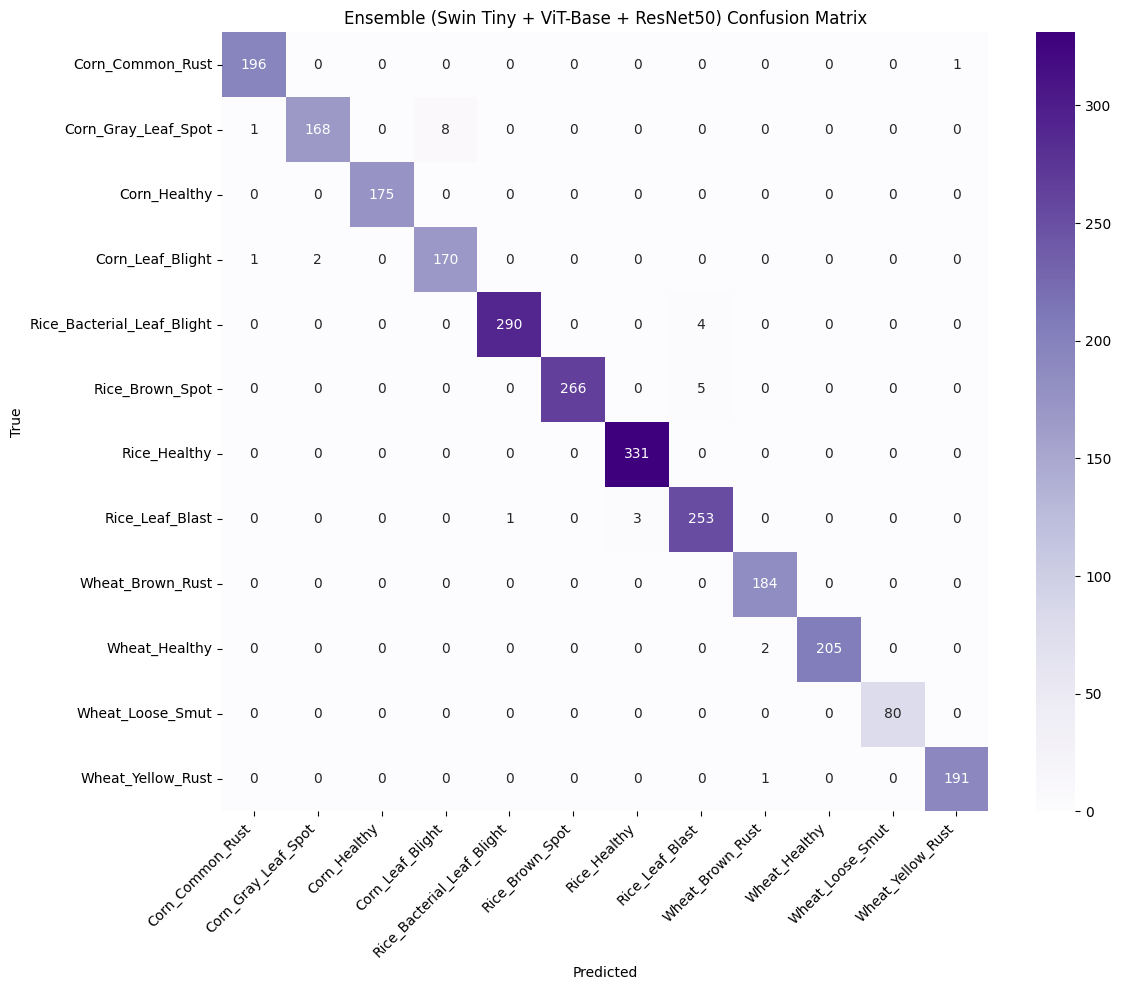

Results saved to: /content/drive/MyDrive/thesis_ensemble_outputs


In [ ]:
output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
os.makedirs(output_folder, exist_ok=True)

with open(f'{output_folder}/ensemble_swin_vit_resnet50_report.txt', 'w') as f:
    f.write(f"Swin Tiny accuracy: {acc_swin:.4f}\n")
    f.write(f"ViT-Base accuracy: {acc_vit:.4f}\n")
    f.write(f"ResNet50 accuracy: {acc_resnet:.4f}\n")
    f.write(f"Ensemble (simple average) accuracy: {acc_ensemble:.4f}\n")
    f.write(f"Best weighted combo [w_swin, w_vit, w_resnet] (tuned on val set): {best_w}\n")
    f.write(f"Ensemble (weighted) test accuracy: {acc_ensemble_weighted:.4f}\n\n")
    f.write(report)

cm = confusion_matrix(true_labels, ensemble_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Purples')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Ensemble (Swin Tiny + ViT-Base + ResNet50) Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{output_folder}/ensemble_swin_vit_resnet50_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Results saved to: {output_folder}")

Cell A ( Grad-CAM setup):

In [14]:
# ============================================================
# Grad-CAM++ setup (CORRECTED: uses pre-softmax logits for gradients,
# not the softmax probability -- avoids vanishing/noisy gradients when
# the model is very confident, i.e. softmax is saturated near 1.0,
# which is the case for nearly every prediction so far)
# Run this cell ONCE, after Cell 8b.
# ============================================================
!pip install opencv-python-headless -q

import cv2
import io
from PIL import Image
from google.colab import files

VIT_GRID = 14
GRADCAM_THRESHOLD = 0.8
MIN_BOX_AREA_FRAC = 0.002

# --- Swin (triple output: spatial features, logits, probabilities) ---
swin_gc_input = layers.Input(shape=(224, 224, 3), dtype='uint8')
swin_base_gc = SwinTransformerTiny224(include_top=False)
swin_spatial = swin_base_gc(swin_gc_input)
x = layers.GlobalAveragePooling2D()(swin_spatial)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
swin_logits = layers.Dense(num_classes, activation=None)(x)
swin_gc_preds = layers.Activation('softmax')(swin_logits)
swin_gc_model = models.Model(swin_gc_input, [swin_spatial, swin_logits, swin_gc_preds])
swin_gc_model.set_weights(swin_model.get_weights())
print("Swin ready (logits exposed)")

# --- ViT-Base (triple output: token sequence, logits, probabilities) ---
vit_backbone_gc = keras_hub.models.ViTBackbone.from_preset("vit_base_patch16_224_imagenet")
vit_backbone_gc.trainable = False
vit_gc_input = layers.Input(shape=(224, 224, 3), dtype='float32')
xn = layers.Lambda(lambda t: (t / 127.5) - 1.0)(vit_gc_input)
vit_seq = vit_backbone_gc(xn)
cls_token = layers.Lambda(lambda t: t[:, 0, :])(vit_seq)
x = layers.Dense(256, activation='relu')(cls_token)
x = layers.Dropout(0.4)(x)
vit_logits = layers.Dense(num_classes, activation=None)(x)
vit_gc_preds = layers.Activation('softmax')(vit_logits)
vit_gc_model = models.Model(vit_gc_input, [vit_seq, vit_logits, vit_gc_preds])
vit_gc_model.set_weights(vit_model.get_weights())
print("ViT ready (logits exposed)")

# --- ResNet50 (triple output: fine-grained 14x14 features, logits, probabilities) ---
resnet_full_gc = tf.keras.applications.ResNet50(include_top=False, weights=None, input_shape=(224, 224, 3))
resnet_feature_extractor = models.Model(
    inputs=resnet_full_gc.input,
    outputs=[resnet_full_gc.get_layer('conv4_block6_out').output, resnet_full_gc.output]
)
resnet_gc_input = layers.Input(shape=(224, 224, 3))
x_pre = tf.keras.applications.resnet50.preprocess_input(resnet_gc_input)
resnet_mid, resnet_final = resnet_feature_extractor(x_pre, training=False)
x = layers.GlobalAveragePooling2D()(resnet_final)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
resnet_logits = layers.Dense(num_classes, activation=None)(x)
resnet_gc_preds = layers.Activation('softmax')(resnet_logits)
resnet_gc_model = models.Model(resnet_gc_input, [resnet_mid, resnet_logits, resnet_gc_preds])
resnet_gc_model.set_weights(resnet_model.get_weights())
print("ResNet50 ready (logits exposed, fine-grained 14x14)")


def gradcam_pp_spatial(model, img_batch):
    """Grad-CAM++ for models whose first output is a (1,H,W,C) spatial map.
    Gradients are computed w.r.t. LOGITS (2nd output), not the softmax
    probability (3rd output), to avoid vanishing gradients at high confidence."""
    img_batch = tf.constant(img_batch)
    with tf.GradientTape() as tape:
        spatial_features, logits, preds = model(img_batch, training=False)
        tape.watch(spatial_features)
        class_idx = tf.argmax(preds[0])
        score = logits[:, class_idx]
    grads = tape.gradient(score, spatial_features)[0]      # (H,W,C)
    features = spatial_features[0]                          # (H,W,C)

    grads_2 = grads ** 2
    grads_3 = grads ** 3
    sum_features = tf.reduce_sum(features, axis=(0, 1), keepdims=True)
    alpha_denom = 2.0 * grads_2 + sum_features * grads_3
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom))
    alphas = grads_2 / alpha_denom
    alpha_norm = tf.reduce_sum(alphas, axis=(0, 1), keepdims=True)
    alpha_norm = tf.where(alpha_norm != 0.0, alpha_norm, tf.ones_like(alpha_norm))
    alphas = alphas / alpha_norm

    weights = tf.reduce_sum(alphas * tf.nn.relu(grads), axis=(0, 1))
    heatmap = tf.reduce_sum(features * weights, axis=-1)
    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(class_idx.numpy()), preds.numpy()[0]


def gradcam_pp_vit_tokens(model, img_batch, grid_size=VIT_GRID):
    """Grad-CAM++ for ViT: first output is the (1,N+1,D) token sequence.
    Gradients computed w.r.t. LOGITS, same reasoning as above."""
    img_batch = tf.constant(img_batch)
    with tf.GradientTape() as tape:
        seq_out, logits, preds = model(img_batch, training=False)
        tape.watch(seq_out)
        class_idx = tf.argmax(preds[0])
        score = logits[:, class_idx]
    grads = tape.gradient(score, seq_out)[0, 1:, :]
    tokens = seq_out[0, 1:, :]

    grads_2 = grads ** 2
    grads_3 = grads ** 3
    sum_tokens = tf.reduce_sum(tokens, axis=0, keepdims=True)
    alpha_denom = 2.0 * grads_2 + sum_tokens * grads_3
    alpha_denom = tf.where(alpha_denom != 0.0, alpha_denom, tf.ones_like(alpha_denom))
    alphas = grads_2 / alpha_denom
    alpha_norm = tf.reduce_sum(alphas, axis=0, keepdims=True)
    alpha_norm = tf.where(alpha_norm != 0.0, alpha_norm, tf.ones_like(alpha_norm))
    alphas = alphas / alpha_norm

    weights = tf.reduce_sum(alphas * tf.nn.relu(grads), axis=0)
    cam = tf.reduce_sum(tokens * weights, axis=-1)
    cam = tf.nn.relu(cam)
    cam = tf.reshape(cam, (grid_size, grid_size))
    cam = cam / (tf.reduce_max(cam) + 1e-8)
    return cam.numpy(), int(class_idx.numpy()), preds.numpy()[0]


def upsample_heatmap(heatmap, size=IMG_SIZE):
    hm = cv2.resize(heatmap.astype(np.float32), size, interpolation=cv2.INTER_CUBIC)
    hm = np.clip(hm, 0, None)
    return hm / (hm.max() + 1e-8)


def combine_heatmaps_consensus(heatmaps, epsilon=1e-6):
    product = np.ones_like(heatmaps[0])
    for hm in heatmaps:
        product = product * (hm + epsilon)
    combined = product ** (1.0 / len(heatmaps))
    combined = combined / (combined.max() + 1e-8)
    return combined


def heatmap_to_bboxes(heatmap, threshold=GRADCAM_THRESHOLD, min_area_frac=MIN_BOX_AREA_FRAC, top_k=1):
    h, w = heatmap.shape
    mask = (heatmap >= threshold).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_area = min_area_frac * h * w
    boxes = []
    for c in contours:
        area = cv2.contourArea(c)
        if area >= min_area:
            x, y, bw, bh = cv2.boundingRect(c)
            severity = float(heatmap[y:y+bh, x:x+bw].mean())
            boxes.append({"x": x, "y": y, "w": bw, "h": bh, "severity": severity, "area": area})
    boxes.sort(key=lambda b: -b["area"])
    if top_k is not None:
        boxes = boxes[:top_k]
    return boxes


def overlay_heatmap(orig_uint8, heatmap, alpha=0.45):
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = orig_uint8.astype(np.float32) * (1 - alpha) + heatmap_color.astype(np.float32) * alpha
    return np.clip(overlay, 0, 255).astype(np.uint8)


def draw_bboxes(orig_uint8, boxes, color=(0, 0, 0), thickness=3):
    img = orig_uint8.copy()
    for b in boxes:
        cv2.rectangle(img, (b["x"], b["y"]), (b["x"] + b["w"], b["y"] + b["h"]), color, thickness)
        label = f"{b['severity']*100:.0f}%"
        (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        tag_x1, tag_y1 = b["x"], max(b["y"] - text_h - 12, 0)
        tag_x2, tag_y2 = tag_x1 + text_w + 10, tag_y1 + text_h + 10
        cv2.rectangle(img, (tag_x1, tag_y1), (tag_x2, tag_y2), (0, 0, 0), -1)
        cv2.putText(img, label, (tag_x1 + 5, tag_y2 - 6), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2, cv2.LINE_AA)
    return img

print("Grad-CAM++ ready (logit fix applied). Run the next cell to upload and test an image.")

Swin ready (logits exposed)
ViT ready (logits exposed)
ResNet50 ready (logits exposed, fine-grained 14x14)
Grad-CAM++ ready (logit fix applied). Run the next cell to upload and test an image.


Cell B

Saving Wheat_Loose_Smut87.jpg to Wheat_Loose_Smut87.jpg
Filename: Wheat_Loose_Smut87.jpg
Predicted class: Wheat_Loose_Smut  (confidence: 100.00%)


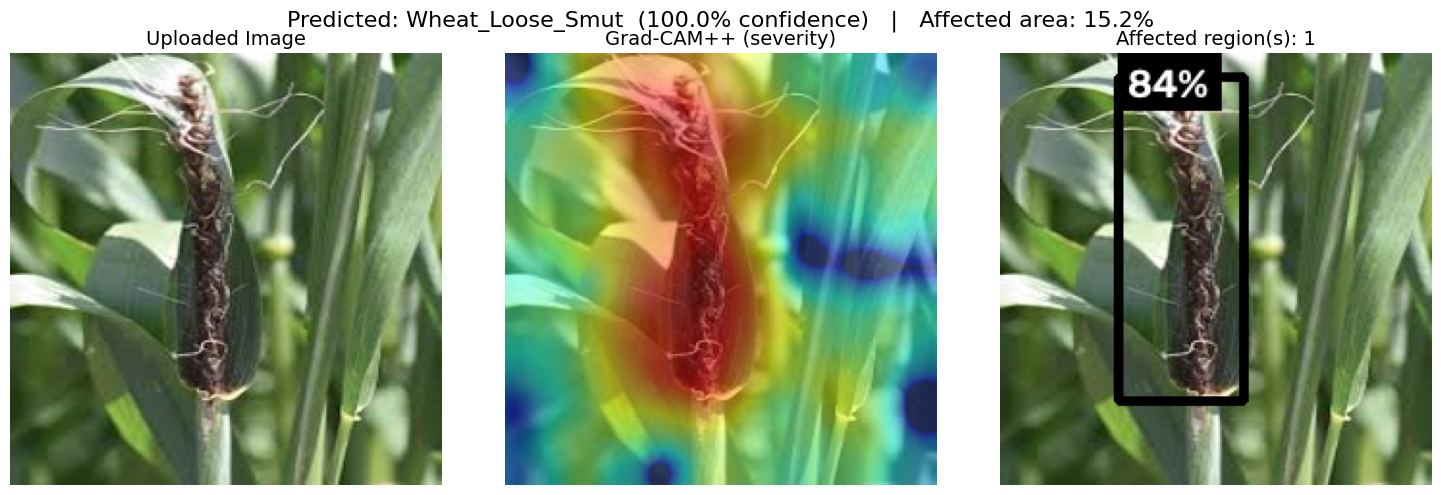

  box at (x=61, y=12, w=65, h=168)  severity=84%


In [32]:
# ============================================================
# Upload a single image and see Grad-CAM++ + bounding box output
# Skips localization for "Healthy" predictions.
# Run this cell again any time to test another image
# ============================================================
uploaded = files.upload()
fname = list(uploaded.keys())[0]

img = Image.open(io.BytesIO(uploaded[fname])).convert('RGB').resize(IMG_SIZE)
raw_uint8 = np.array(img).astype(np.uint8)
raw_float32 = raw_uint8.astype(np.float32)

batch_uint8 = np.expand_dims(raw_uint8, 0)
batch_float32 = np.expand_dims(raw_float32, 0)

hm_swin, _, preds_swin = gradcam_pp_spatial(swin_gc_model, batch_uint8)
hm_vit, _, preds_vit = gradcam_pp_vit_tokens(vit_gc_model, batch_float32)
hm_resnet, _, preds_resnet = gradcam_pp_spatial(resnet_gc_model, batch_float32)

ensemble_probs = (preds_swin + preds_vit + preds_resnet) / 3.0
class_idx = int(np.argmax(ensemble_probs))
pred_label = class_names[class_idx]
confidence = float(ensemble_probs[class_idx])

print(f"Filename: {fname}")
print(f"Predicted class: {pred_label}  (confidence: {confidence*100:.2f}%)")

if 'healthy' in pred_label.lower():
    plt.figure(figsize=(5, 5))
    plt.imshow(raw_uint8)
    plt.title(f"Predicted: {pred_label}  ({confidence*100:.1f}% confidence)\nNo disease detected", fontsize=15)
    plt.axis("off")
    plt.show()

else:
    hm_swin_up = upsample_heatmap(hm_swin)
    hm_vit_up = upsample_heatmap(hm_vit)
    hm_resnet_up = upsample_heatmap(hm_resnet)

    combined = combine_heatmaps_consensus([hm_swin_up, hm_vit_up, hm_resnet_up])
    boxes = heatmap_to_bboxes(combined)
    affected_area_pct = 100.0 * float(np.sum(combined >= GRADCAM_THRESHOLD)) / combined.size

    overlay_img = overlay_heatmap(raw_uint8, combined)
    bbox_img = draw_bboxes(raw_uint8, boxes)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(raw_uint8); axes[0].set_title("Uploaded Image", fontsize=14); axes[0].axis("off")
    axes[1].imshow(overlay_img); axes[1].set_title("Grad-CAM++ (severity)", fontsize=14); axes[1].axis("off")
    axes[2].imshow(bbox_img); axes[2].set_title(f"Affected region(s): {len(boxes)}", fontsize=14); axes[2].axis("off")
    fig.suptitle(f"Predicted: {pred_label}  ({confidence*100:.1f}% confidence)   |   Affected area: {affected_area_pct:.1f}%", fontsize=16)
    plt.tight_layout()
    plt.show()

    for b in boxes:
        print(f"  box at (x={b['x']}, y={b['y']}, w={b['w']}, h={b['h']})  severity={b['severity']*100:.0f}%")

In [ ]:
# ============================================================
# McNemar's test: best single model (ViT, 98.38%) vs best ensemble
# (Swin + ViT + ResNet50, 98.86%). Tests whether the ensemble's
# accuracy improvement over the single best model is statistically
# significant, or could just be random chance/noise.
# ============================================================
!pip install statsmodels -q
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# Uses variables already computed earlier in this notebook:
#   pred_vit_labels  -- single ViT predictions (Cell 10)
#   ensemble_preds   -- Swin+ViT+ResNet50 simple-average ensemble predictions (Cell 10)
#   true_labels      -- ground truth (Cell 4)

vit_correct = (pred_vit_labels == true_labels)
ensemble_correct = (ensemble_preds == true_labels)

n11 = int(np.sum(vit_correct & ensemble_correct))     # both correct
n10 = int(np.sum(vit_correct & ~ensemble_correct))    # ViT correct, ensemble wrong
n01 = int(np.sum(~vit_correct & ensemble_correct))    # ViT wrong, ensemble correct
n00 = int(np.sum(~vit_correct & ~ensemble_correct))   # both wrong

table = [[n11, n10], [n01, n00]]
print("Contingency table (ViT vs Ensemble):")
print(f"  Both correct:                    {n11}")
print(f"  ViT correct, Ensemble wrong:     {n10}")
print(f"  ViT wrong, Ensemble correct:     {n01}")
print(f"  Both wrong:                      {n00}")

result = mcnemar(table, exact=(n10 + n01 < 25), correction=True)
print(f"\nMcNemar's test statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.6f}")

alpha = 0.05
if result.pvalue < alpha:
    print(f"\np < {alpha} --> The accuracy difference IS statistically significant.")
else:
    print(f"\np >= {alpha} --> The accuracy difference is NOT statistically significant (could be due to chance).")

Contingency table (ViT vs Ensemble):
  Both correct:                    2487
  ViT correct, Ensemble wrong:     6
  ViT wrong, Ensemble correct:     22
  Both wrong:                      23

McNemar's test statistic: 8.0357
p-value: 0.004586

p < 0.05 --> The accuracy difference IS statistically significant.


Saving Wheat_Loose_Smut87.jpg to Wheat_Loose_Smut87 (1).jpg
Filename: Wheat_Loose_Smut87 (1).jpg
Full-image prediction: Wheat_Loose_Smut (100.0% confidence)
Scanning patches (this takes a minute)...


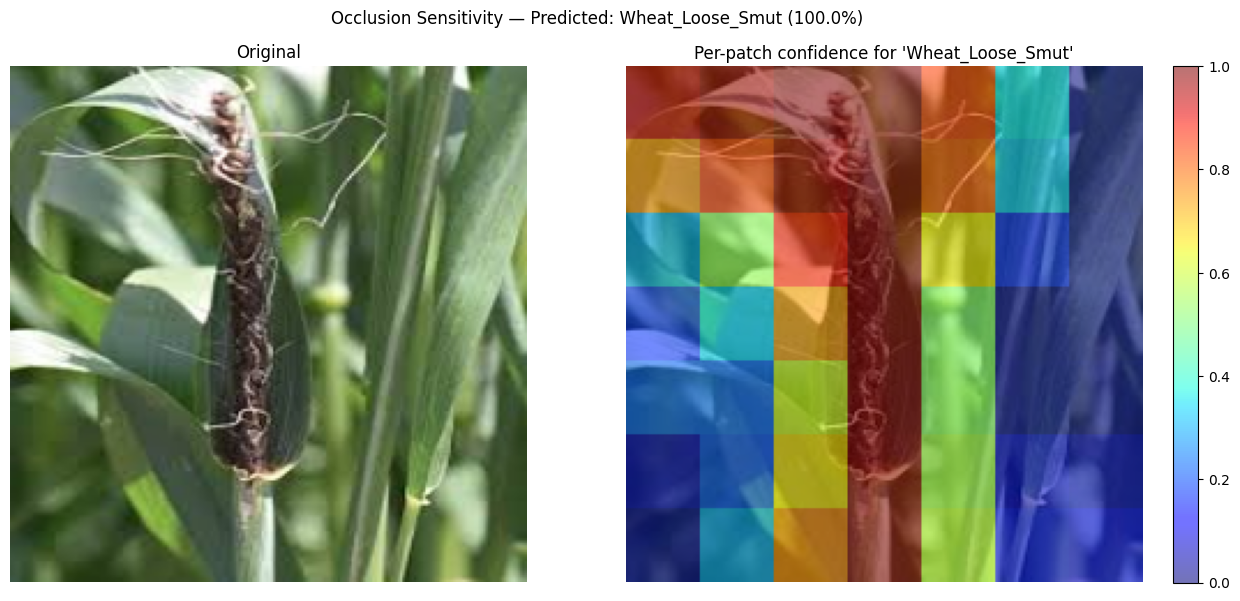


Saved to: /content/drive/MyDrive/thesis_ensemble_outputs/occlusion_test_Wheat_Loose_Smut87 (1).png

If patches far from the visible lesion ALSO show high (red/yellow)
confidence here, that's direct evidence the model isn't relying on
the lesion itself to make its prediction.


In [33]:
# ============================================================
# Cell C — Occlusion sensitivity test (independent, gradient-free
# cross-check for Grad-CAM++). Run this AFTER Cell A (reuses its
# swin_gc_model / vit_gc_model / resnet_gc_model).
# Slides a small patch across the image and measures the ensemble's
# OWN prediction confidence using ONLY that patch -- no gradients,
# no backprop. If confidence stays high even on lesion-free patches,
# that's direct evidence the model isn't relying on the lesion alone.
# ============================================================
PATCH_SIZE = 64
STRIDE = 32

def predict_ensemble_occlusion(img_uint8):
    batch_uint8 = np.expand_dims(img_uint8, 0)
    batch_float32 = np.expand_dims(img_uint8.astype(np.float32), 0)
    # Cell A's models return 3 outputs each: (features, logits, probabilities)
    _, _, preds_swin = swin_gc_model.predict(batch_uint8, verbose=0)
    _, _, preds_vit = vit_gc_model.predict(batch_float32, verbose=0)
    _, _, preds_resnet = resnet_gc_model.predict(batch_float32, verbose=0)
    return (preds_swin[0] + preds_vit[0] + preds_resnet[0]) / 3.0

uploaded = files.upload()
fname = list(uploaded.keys())[0]
img = Image.open(io.BytesIO(uploaded[fname])).convert('RGB').resize(IMG_SIZE)
raw_uint8 = np.array(img).astype(np.uint8)

full_probs = predict_ensemble_occlusion(raw_uint8)
target_class = int(np.argmax(full_probs))
target_label = class_names[target_class]
print(f"Filename: {fname}")
print(f"Full-image prediction: {target_label} ({full_probs[target_class]*100:.1f}% confidence)")
print("Scanning patches (this takes a minute)...")

H, W = IMG_SIZE
confidence_map = np.zeros((H, W))
count_map = np.zeros((H, W))

positions = list(range(0, H - PATCH_SIZE + 1, STRIDE))
for py in positions:
    for px in positions:
        patch = raw_uint8[py:py+PATCH_SIZE, px:px+PATCH_SIZE]
        patch_resized = np.array(Image.fromarray(patch).resize(IMG_SIZE))
        probs = predict_ensemble_occlusion(patch_resized)
        conf = probs[target_class]
        confidence_map[py:py+PATCH_SIZE, px:px+PATCH_SIZE] += conf
        count_map[py:py+PATCH_SIZE, px:px+PATCH_SIZE] += 1

count_map[count_map == 0] = 1
confidence_map = confidence_map / count_map

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
axes[0].imshow(raw_uint8); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(raw_uint8)
im = axes[1].imshow(confidence_map, cmap='jet', vmin=0, vmax=1, alpha=0.55)
axes[1].set_title(f"Per-patch confidence for '{target_label}'")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046)
fig.suptitle(f"Occlusion Sensitivity — Predicted: {target_label} ({full_probs[target_class]*100:.1f}%)", fontsize=12)
plt.tight_layout()

output_folder = '/content/drive/MyDrive/thesis_ensemble_outputs'
plt.savefig(f'{output_folder}/occlusion_test_{fname.split(".")[0]}.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"\nSaved to: {output_folder}/occlusion_test_{fname.split('.')[0]}.png")

print("\nIf patches far from the visible lesion ALSO show high (red/yellow)")
print("confidence here, that's direct evidence the model isn't relying on")
print("the lesion itself to make its prediction.")

Cell D (Spearman rank correlation — Grad-CAM++ vs Occlusion Sensitivity):
Quantifies agreement between the two independent explainability methods on THIS image.
Run after Cell C.


In [ ]:
# ============================================================
# Spearman rank correlation: does Grad-CAM++ agree with Occlusion
# Sensitivity on WHICH regions matter for this prediction?
# occlusion_map is "confidence retained" (high = LESS important), so it
# is inverted (1 - value) before correlating with Grad-CAM++ importance.
# ============================================================
!pip install scipy -q
from scipy.stats import spearmanr
from scipy.ndimage import zoom

def compare_gradcam_occlusion(gradcam_map, occlusion_map, occlusion_is_confidence=True):
    gradcam_map = np.asarray(gradcam_map, dtype=np.float64)
    occlusion_map = np.asarray(occlusion_map, dtype=np.float64)
    occlusion_importance = (1.0 - occlusion_map) if occlusion_is_confidence else occlusion_map

    target_shape = occlusion_importance.shape
    zf = (target_shape[0] / gradcam_map.shape[0], target_shape[1] / gradcam_map.shape[1])
    gradcam_resized = zoom(gradcam_map, zf, order=1)

    rho, pval = spearmanr(gradcam_resized.flatten(), occlusion_importance.flatten())

    if pval > 0.05:
        strength = "NOT statistically significant (p > 0.05)"
    elif abs(rho) >= 0.7:
        strength = "strong agreement" if rho > 0 else "strong disagreement (inverse)"
    elif abs(rho) >= 0.4:
        strength = "moderate agreement" if rho > 0 else "moderate disagreement (inverse)"
    elif abs(rho) >= 0.2:
        strength = "weak agreement" if rho > 0 else "weak disagreement (inverse)"
    else:
        strength = "negligible / no monotonic relationship"
    return rho, pval, strength


def top_k_overlap(gradcam_map, occlusion_map, occlusion_is_confidence=True, k_percent=20.0):
    gradcam_map = np.asarray(gradcam_map, dtype=np.float64)
    occlusion_map = np.asarray(occlusion_map, dtype=np.float64)
    occlusion_importance = (1.0 - occlusion_map) if occlusion_is_confidence else occlusion_map

    target_shape = occlusion_importance.shape
    zf = (target_shape[0] / gradcam_map.shape[0], target_shape[1] / gradcam_map.shape[1])
    gradcam_resized = zoom(gradcam_map, zf, order=1).flatten()
    occlusion_flat = occlusion_importance.flatten()

    n = gradcam_resized.size
    k = max(1, int(round(n * k_percent / 100.0)))
    top_gradcam = set(np.argsort(gradcam_resized)[-k:])
    top_occlusion = set(np.argsort(occlusion_flat)[-k:])
    intersection = top_gradcam & top_occlusion
    union = top_gradcam | top_occlusion
    iou = len(intersection) / len(union) if union else 0.0
    return iou, len(intersection), k


rho, pval, strength = compare_gradcam_occlusion(combined, confidence_map, occlusion_is_confidence=False)
iou, n_overlap, k = top_k_overlap(combined, confidence_map, occlusion_is_confidence=False, k_percent=20)

print(f"Image: {fname}")
print(f"Predicted class: {pred_label} ({confidence*100:.2f}%)")
print(f"Spearman rho = {rho:.4f}  (p = {pval:.4g})")
print(f"Interpretation: {strength}")
print(f"Top-20% patch overlap (IoU): {iou:.3f}  ({n_overlap} overlapping / {k} patches per method)")


Image: Wheat_Loose_Smut87 (1).jpg
Predicted class: Wheat_Loose_Smut (100.00%)
Spearman rho = 0.7075  (p = 0)
Interpretation: strong agreement
Top-20% patch overlap (IoU): 0.493  (6628 overlapping / 10035 patches per method)
